In [0]:
import pandas as pd
import numpy as np

In [0]:
df = spark.table("workspace.default.`1782321019230_patient_readmission`").toPandas()
df.head()

,Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
0,1,62,Female,Elective,4,5,110,130,1,No
1,2,65,Male,Emergency,19,2,157,81,4,No
2,3,82,Female,Emergency,18,4,74,84,0,No
3,4,85,Male,Emergency,2,4,106,85,4,No
4,5,85,Female,Elective,19,3,80,119,3,No


In [0]:
df.shape

(3000, 10)

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient ID           3000 non-null   int64 
 1   Age                  3000 non-null   int64 
 2   Gender               3000 non-null   object
 3   Admission Type       3000 non-null   object
 4   Length of Stay       3000 non-null   int64 
 5   Number of Diagnoses  3000 non-null   int64 
 6   Blood Pressure       3000 non-null   int64 
 7   Blood Sugar Levels   3000 non-null   int64 
 8   Previous Admissions  3000 non-null   int64 
 9   Readmission          3000 non-null   object
dtypes: int64(7), object(3)
memory usage: 234.5+ KB


In [0]:
# Assuming the data had nulls, this would be the code to show exactly how many nulls per columns if summed together:

df.isnull().sum()

Patient ID             0
Age                    0
Gender                 0
Admission Type         0
Length of Stay         0
Number of Diagnoses    0
Blood Pressure         0
Blood Sugar Levels     0
Previous Admissions    0
Readmission            0
dtype: int64

<Axes: >

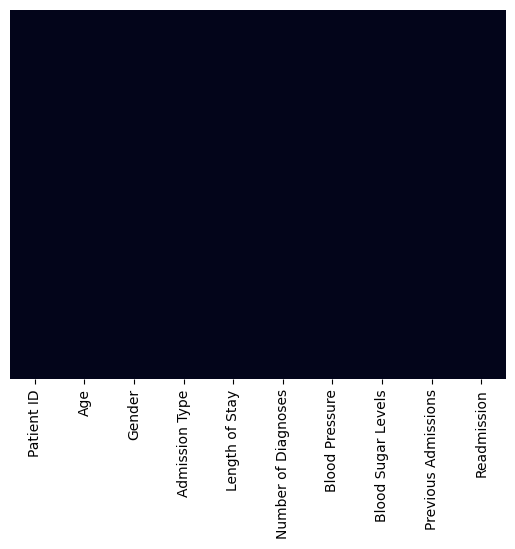

In [0]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

In [0]:
df['Gender'].value_counts()

Male      1555
Female    1445
Name: Gender, dtype: int64

In [0]:
df['Admission Type'].value_counts()

Elective     1563
Emergency    1437
Name: Admission Type, dtype: int64

In [0]:
df['Readmission'].value_counts()

No     2134
Yes     866
Name: Readmission, dtype: int64

In [0]:
df['Gender'].nunique()

2

In [0]:
df['Admission Type'].nunique()

2

In [0]:
df['Readmission'].nunique()

2

In [0]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [0]:
df['Admission Type'].unique()

array(['Elective', 'Emergency'], dtype=object)

In [0]:
df['Readmission'].unique()

array(['No', 'Yes'], dtype=object)

### Visuals:

<Axes: >

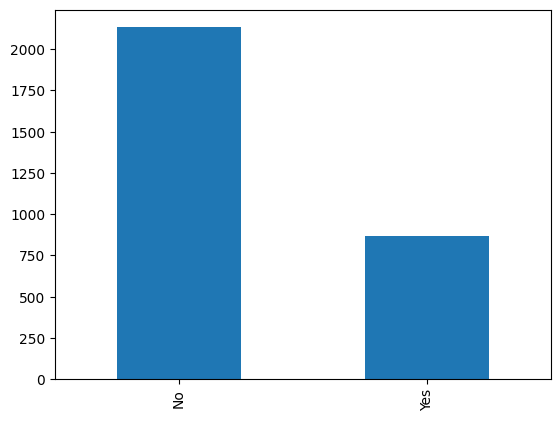

In [0]:
df['Readmission'].value_counts().plot(kind ='bar')

<Axes: >

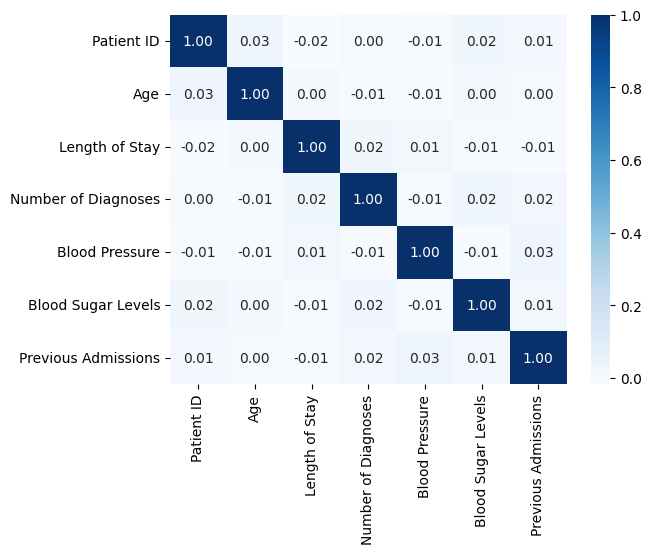

In [0]:
sns.heatmap(df.corr(numeric_only=True, method = "spearman"),annot=True, fmt=".2f", cmap= "Blues")

In [0]:

'''sns.heatmap(
    encoded_df[cat_cols].corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.show()'''

cat_col = [['Gender','Admission Type','Readmission']]
sns.heatmap(df[cat_col].corr(method = "spearman"),annot=True, fmt=".2f", cmap= "Blues")

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-6515819770616011>, line 10
      1 '''sns.heatmap(
      2     encoded_df[cat_cols].corr(method='spearman'),
      3     annot=True,
   (...)
      6 )
      7 plt.show()'''
      9 cat_col = [['Gender','Admission Type','Readmission']]
---> 10 sns.heatmap(df[cat_col].corr(method = "spearman"),annot=True, fmt=".2f", cmap= "Blues")

File /databricks/python/lib/python3.11/site-packages/pandas/core/frame.py:3813, in DataFrame.__getitem__(self, key)
   3811     if is_iterator(key):
   3812         key = list(key)
-> 3813     indexer = self.columns._get_indexer_strict(key, "columns")[1]
   3815 # take() does not accept boolean indexers
   3816 if getattr(indexer, "dtype", None) == bool:

File /databricks/python/lib/python3.11/site-packages/pandas/core/indexes/base.py:6070, in Index._get_indexer_strict(self, key, axis_name)
   60